## Homework 3 (KNN)
Дз по KNN-ну (я использовал датасет Anemia Types Classification https://www.kaggle.com/datasets/ehababoelnaga/anemia-types-classification/data?select=diagnosed_cbc_data_v4.csv) 

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('diagnosed_cbc_data_v4.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   WBC        1281 non-null   float64
 1   LYMp       1281 non-null   float64
 2   NEUTp      1281 non-null   float64
 3   LYMn       1281 non-null   float64
 4   NEUTn      1281 non-null   float64
 5   RBC        1281 non-null   float64
 6   HGB        1281 non-null   float64
 7   HCT        1281 non-null   float64
 8   MCV        1281 non-null   float64
 9   MCH        1281 non-null   float64
 10  MCHC       1281 non-null   float64
 11  PLT        1281 non-null   float64
 12  PDW        1281 non-null   float64
 13  PCT        1281 non-null   float64
 14  Diagnosis  1281 non-null   str    
dtypes: float64(14), str(1)
memory usage: 150.2 KB


## Обзор датасета

Датасет не имеет пропусков, типы данных вполне адекватные, датасет достаточно большой (1281 сэмплов), различных классов много, а именно:

In [42]:
diagnoses = pd.Series(df['Diagnosis'].unique())
print(diagnoses)
print('количество классов - {}'.format(len(diagnoses)))


0     Normocytic hypochromic anemia
1            Iron deficiency anemia
2           Other microcytic anemia
3                          Leukemia
4                           Healthy
5                  Thrombocytopenia
6    Normocytic normochromic anemia
7    Leukemia with thrombocytopenia
8                 Macrocytic anemia
dtype: str
количество классов - 9


И по количеству сэмплов разные классы насчитывают:

In [43]:
print(pd.DataFrame({diagnosis: df[df['Diagnosis'] == diagnosis].shape[0] for diagnosis in diagnoses}.items()))

                                0    1
0   Normocytic hypochromic anemia  279
1          Iron deficiency anemia  189
2         Other microcytic anemia   59
3                        Leukemia   47
4                         Healthy  336
5                Thrombocytopenia   73
6  Normocytic normochromic anemia  269
7  Leukemia with thrombocytopenia   11
8               Macrocytic anemia   18


Теперь посмотрим на распределения данных:

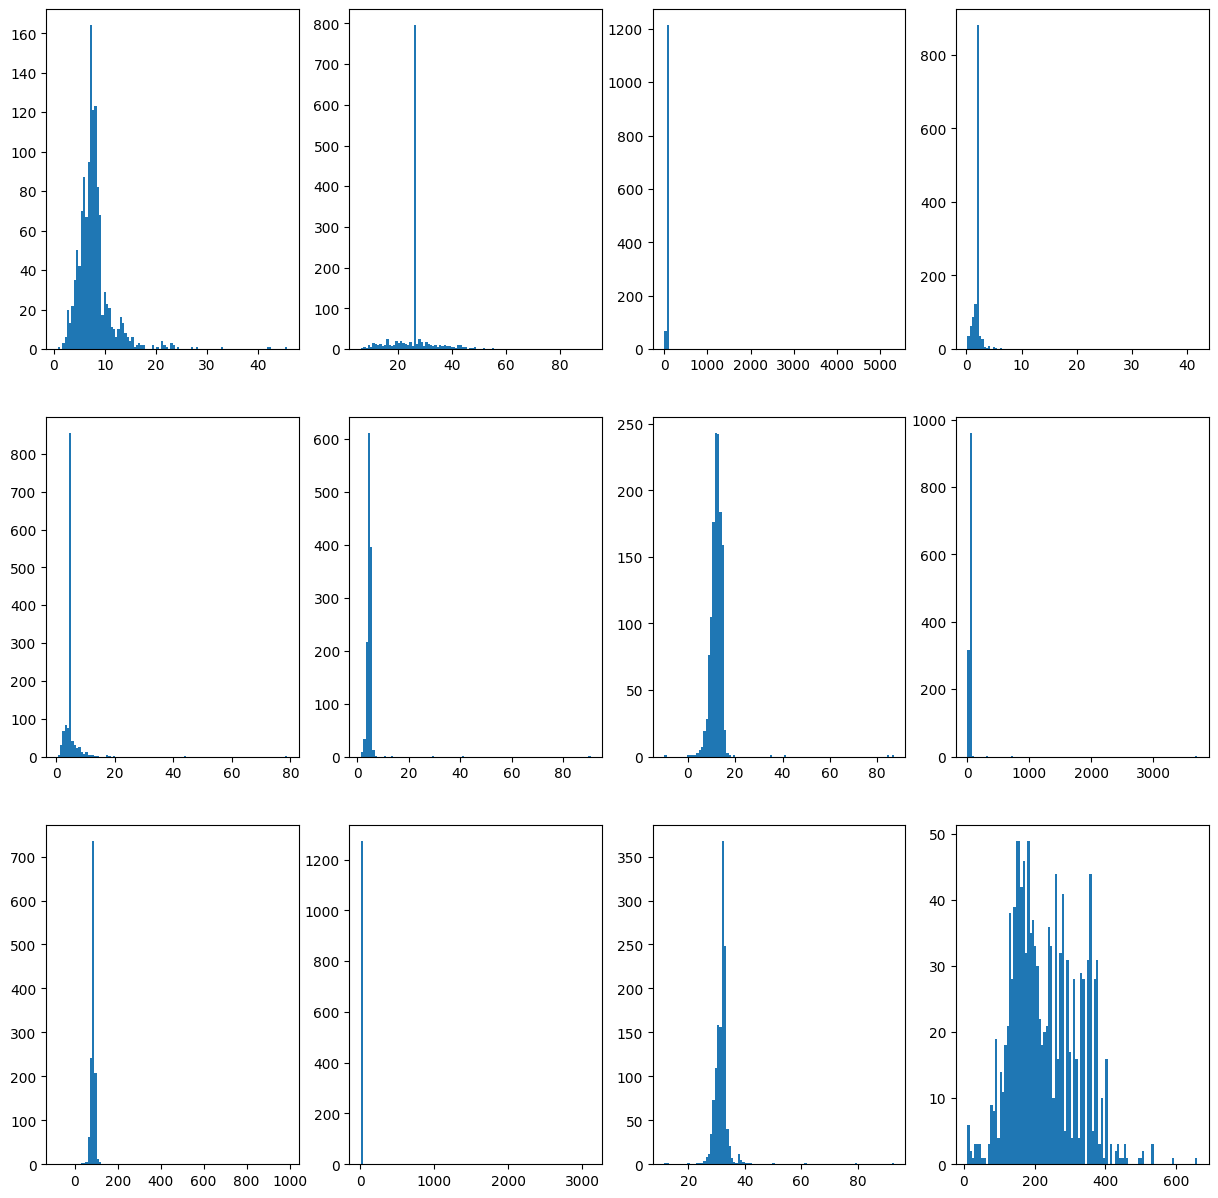

In [44]:
from matplotlib import pyplot as plt

for ax, title in zip(plt.figure(figsize=(15,15)).subplots(3, 4).ravel(), df.select_dtypes('number').columns):
    ax.hist(df[title].values, bins=100)
    ax.set_xlabel('')


Посмотрим на то, как признаки распределены по значениям (сильно ли отличаются диапазоны), просчитаем это и визуализируем.

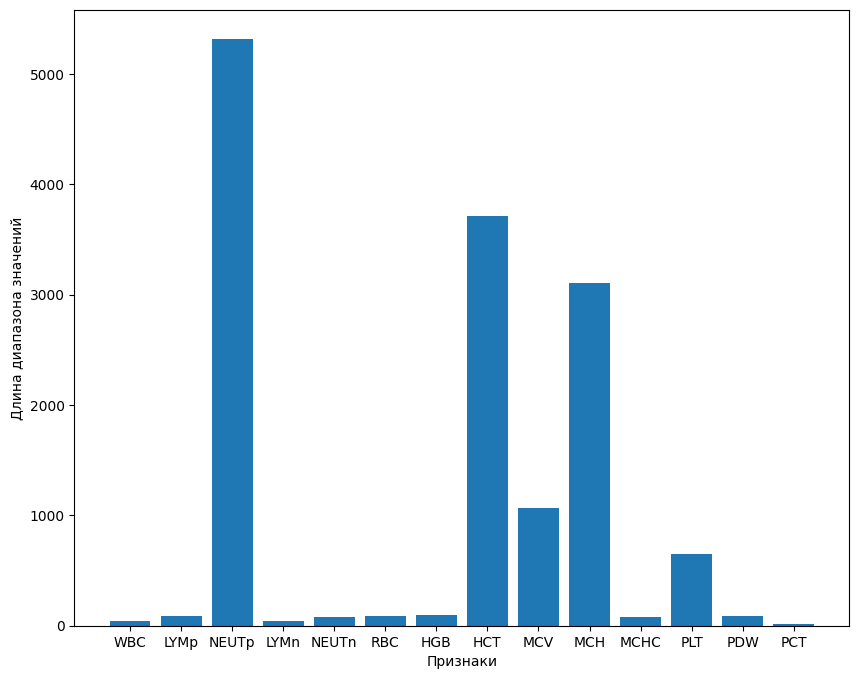

In [45]:


column_ranges = pd.Series(abs(df.select_dtypes('number').max().values - df.select_dtypes('number').min().values), index=df.select_dtypes('number').columns)
plt.figure(figsize=(10, 8))
plt.bar(range(len(column_ranges)), column_ranges)
plt.xticks(range(len(column_ranges)), column_ranges.index)
plt.xlabel('Признаки')
plt.ylabel('Длина диапазона значений')
plt.show()

Как видно на графике, разброс между диапазонами по величинам большой, поэтому нужно занятся масштабированием (в следующем пункте), т.к. в KNN используются метрики, которые чувствительны к таким различиям.

## Подготовка данных
Для начала попробуем масштабировать датасет.

In [48]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
df_scaled = pd.DataFrame(sc.fit_transform(df.select_dtypes('number'))).join(df['Diagnosis'])
df_scaled.columns = df.columns
df_scaled.head()

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,0.599843,2.466607,-0.185600,1.811937,-0.049088,-0.688280,-1.281561,-0.209381,0.070161,-0.052056,-0.496853,-0.440741,-0.603385,-0.131780,Normocytic hypochromic anemia
1,0.599843,2.352906,-0.170704,1.737040,0.055399,-0.663423,-1.281561,-0.201751,0.088566,-0.057455,-3.497704,-0.537533,-0.603385,-0.146376,Normocytic hypochromic anemia
2,-0.185996,0.690025,-0.113827,0.239101,-0.258062,-0.262159,-0.835531,-0.149293,-0.323698,-0.085351,-0.678723,-0.881682,-0.004165,-0.175570,Iron deficiency anemia
3,-0.522784,0.618961,-0.094869,-0.060487,-0.467036,-0.173384,-2.199856,-0.127355,-0.290570,-0.079952,-0.587788,-0.935455,-1.002865,-0.204763,Iron deficiency anemia
4,-1.027965,1.883888,-0.161224,-0.210281,-0.989470,-0.276363,-3.091915,2.573771,-0.191184,-0.073653,-0.618099,0.064728,-0.503515,-0.058796,Normocytic hypochromic anemia


Теперь построим еще раз график диапазонов значений, но уже для масштабированного датасета

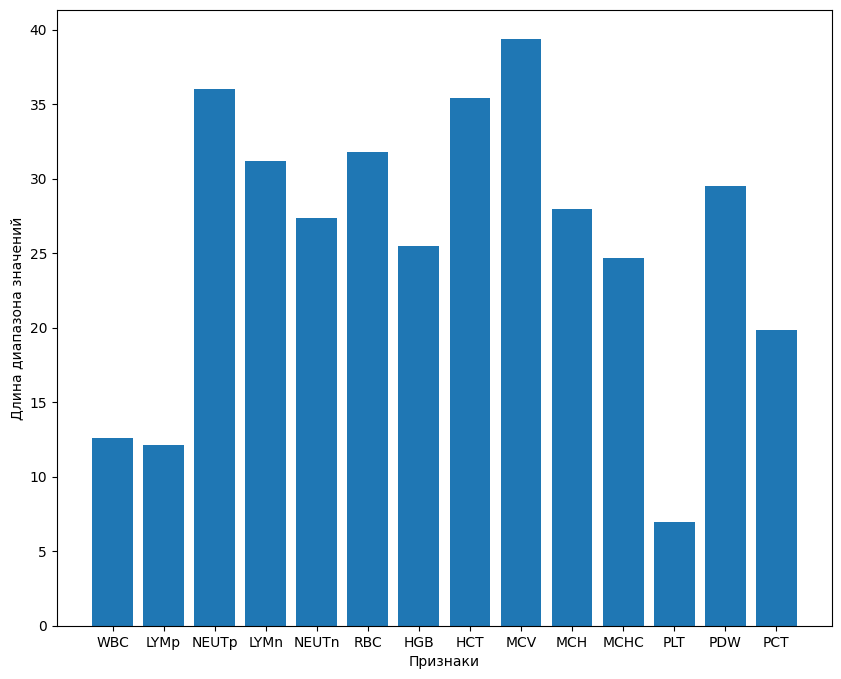

In [50]:
column_ranges = pd.Series(abs(df_scaled.select_dtypes('number').max().values - df_scaled.select_dtypes('number').min().values), index=df_scaled.select_dtypes('number').columns)
plt.figure(figsize=(10, 8))
plt.bar(range(len(column_ranges)), column_ranges)
plt.xticks(range(len(column_ranges)), column_ranges.index)
plt.xlabel('Признаки')
plt.ylabel('Длина диапазона значений')
plt.show()

Как видно на графике, данные теперь имеют схожие диапазоны, но можно попробовать и другие скейлеры: